# Module 2: Introduction to Statistical Inference

This module introduces the core concepts of statistical inference. We will explore how we use samples to make generalizations (inferences) about populations.

### Learning Objectives:
- Understand and apply various sampling methods (Simple Random, Stratified, Cluster).
- Define and calculate point estimates.
- Understand the properties of estimators (Bias and Efficiency).
- Visualize and understand the Central Limit Theorem (CLT).

In [1]:
# Setup: Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
np.random.seed(42) # for reproducibility
print("Setup Complete")

Setup Complete


## Section 1: Sampling Theory

Sampling is the process of selecting a subset from a population to estimate characteristics of the whole population. Proper sampling methods are essential for valid inferences.

Let's create a hypothetical population dataset to work with.

In [2]:
# Create a diverse population dataset
# Imagine a university with students in different faculties.
data = []
# 1000 students in Arts (Lower average GPA)
data.extend([{'Faculty': 'Arts', 'GPA': np.random.normal(2.8, 0.5)} for _ in range(1000)])
# 800 students in Science (Higher average GPA)
data.extend([{'Faculty': 'Science', 'GPA': np.random.normal(3.2, 0.4)} for _ in range(800)])
# 500 students in Engineering (Highest average GPA, less variance)
data.extend([{'Faculty': 'Engineering', 'GPA': np.random.normal(3.5, 0.3)} for _ in range(500)])

population_df = pd.DataFrame(data)
# Ensure GPA is capped at 4.0 and floored at 0.0
population_df['GPA'] = population_df['GPA'].apply(lambda x: max(0.0, min(x, 4.0)))

population_mean_gpa = population_df['GPA'].mean()

print(f"Total Population Size: {len(population_df)}")
print(f"Population Mean GPA (True Parameter μ): {population_mean_gpa:.4f}")
print("\nPopulation distribution by Faculty:")
print(population_df['Faculty'].value_counts(normalize=True))

Total Population Size: 2300
Population Mean GPA (True Parameter μ): 3.1029

Population distribution by Faculty:
Faculty
Arts           0.434783
Science        0.347826
Engineering    0.217391
Name: proportion, dtype: float64


### 1.1 Simple Random Sampling (SRS)

Every member of the population has an equal chance of being selected. This is the simplest method.

In [3]:
# Goal: Select a sample of 100 students using SRS.
sample_size = 100
srs_sample = population_df.sample(n=sample_size, random_state=1)

srs_mean_gpa = srs_sample['GPA'].mean()
print(f"SRS Sample Mean GPA (Estimate x̄): {srs_mean_gpa:.4f}")
print("\nSRS Sample distribution by Faculty (may differ from population):")
print(srs_sample['Faculty'].value_counts(normalize=True))

SRS Sample Mean GPA (Estimate x̄): 3.1941

SRS Sample distribution by Faculty (may differ from population):
Faculty
Arts           0.38
Science        0.36
Engineering    0.26
Name: proportion, dtype: float64


### 1.2 Stratified Sampling

The population is divided into subgroups (strata) based on shared characteristics (e.g., Faculty). SRS is then performed within each stratum. This ensures the sample structure mirrors the population structure.

In [4]:
# Goal: Select a sample of 100 students, ensuring proportional representation of faculties.

# Using pandas groupby and sample with frac (fraction) to perform stratified sampling
# We calculate the fraction needed overall and apply it to each group.
fraction = sample_size / len(population_df)

stratified_sample = population_df.groupby('Faculty', group_keys=False).apply(
    lambda x: x.sample(frac=fraction, random_state=1)
)

stratified_mean_gpa = stratified_sample['GPA'].mean()
print(f"Stratified Sample Mean GPA (Estimate x̄): {stratified_mean_gpa:.4f}")
print("\nStratified Sample distribution by Faculty (closely matches population):")
print(stratified_sample['Faculty'].value_counts(normalize=True))

Stratified Sample Mean GPA (Estimate x̄): 3.0636

Stratified Sample distribution by Faculty (closely matches population):
Faculty
Arts           0.43
Science        0.35
Engineering    0.22
Name: proportion, dtype: float64


/tmp/ipython-input-3351509357.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratified_sample = population_df.groupby('Faculty', group_keys=False).apply(


### 1.3 Cluster Sampling

The population is divided into clusters (e.g., dorm buildings). A random sample of clusters is selected, and then members from those selected clusters are surveyed. This is often more practical than SRS.

In [5]:
# Add Dorm Buildings (Clusters) to the population
dorms = [f'Dorm_{i}' for i in range(1, 11)] # 10 dorms
# Assign students randomly to dorms
population_df['Dorm'] = np.random.choice(dorms, size=len(population_df))

# Goal: Select a sample by randomly choosing 2 dorms (clusters) and surveying everyone in those dorms.

selected_clusters = np.random.choice(dorms, size=2, replace=False)
print(f"Selected Clusters: {selected_clusters}")

# Select all individuals within the chosen clusters
cluster_sample = population_df[population_df['Dorm'].isin(selected_clusters)]

cluster_mean_gpa = cluster_sample['GPA'].mean()
print(f"\nCluster Sample Size: {len(cluster_sample)}")
print(f"Cluster Sample Mean GPA (Estimate x̄): {cluster_mean_gpa:.4f}")

Selected Clusters: ['Dorm_1' 'Dorm_6']

Cluster Sample Size: 498
Cluster Sample Mean GPA (Estimate x̄): 3.1060


## Section 2: Point Estimation and Properties of Estimators

A **point estimate** is a single value used to estimate an unknown population parameter. The sample mean ($\bar{x}$) is a point estimator for the population mean ($\mu$).

We want our estimators to be good. Key properties include:

1.  **Unbiasedness:** On average, the estimator equals the true parameter.
2.  **Efficiency (Low Variance):** The estimator doesn't vary much from sample to sample.
3.  **Consistency:** As the sample size increases, the estimator converges to the true parameter.

Let's compare the estimates from our different methods.

In [6]:
print(f"True Population Mean (μ): {population_mean_gpa:.4f}\n")
print(f"SRS Estimate:         {srs_mean_gpa:.4f} (Error: {srs_mean_gpa - population_mean_gpa:.4f})")
print(f"Stratified Estimate:  {stratified_mean_gpa:.4f} (Error: {stratified_mean_gpa - population_mean_gpa:.4f})")
print(f"Cluster Estimate:     {cluster_mean_gpa:.4f} (Error: {cluster_mean_gpa - population_mean_gpa:.4f})")

# Stratified sampling often yields the lowest error (highest efficiency) when strata are meaningful, as it reduces variance.

True Population Mean (μ): 3.1029

SRS Estimate:         3.1941 (Error: 0.0912)
Stratified Estimate:  3.0636 (Error: -0.0393)
Cluster Estimate:     3.1060 (Error: 0.0031)


### 2.1 Demonstrating Unbiasedness of the Sample Mean

The sample mean is an unbiased estimator. If we take many, many samples, the average of those sample means (the expected value of the estimator, $E[\bar{x}]$) will approach the true population mean ($\mu$).

In [7]:
sample_means = []
num_simulations = 5000

# Take 5000 samples (each of size 50) using SRS and record their means
for _ in range(num_simulations):
    # We sample directly from the GPA column
    sample = population_df['GPA'].sample(n=50)
    sample_means.append(sample.mean())

# Calculate the average of the sample means
average_of_sample_means = np.mean(sample_means)

print(f"True Population Mean (μ): {population_mean_gpa:.4f}")
print(f"Average of 5000 Sample Means (E[x̄]): {average_of_sample_means:.4f}")

# Since E[x̄] ≈ μ, the estimator is demonstrated to be unbiased.

True Population Mean (μ): 3.1029
Average of 5000 Sample Means (E[x̄]): 3.1009


## Section 3: The Central Limit Theorem (CLT)

The Central Limit Theorem (CLT) is fundamental to statistical inference.

It states that the **sampling distribution of the sample mean** will approach a normal distribution as the sample size (n) increases, regardless of the shape of the original population distribution.

Furthermore:
1. The mean of the sampling distribution is the population mean (μ).
2. The standard deviation of the sampling distribution (Standard Error) is $\sigma / \sqrt{n}$.

### 3.1 Demonstration of CLT

Let's start with a population that is clearly NOT normally distributed (e.g., an Exponential distribution).

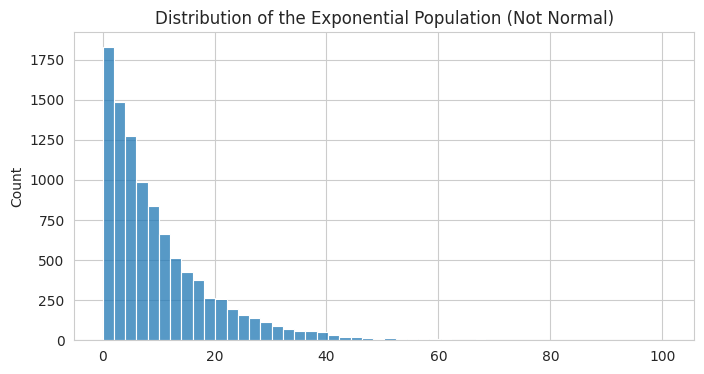

Population Mean: 9.96


In [8]:
# Create an Exponential population (Highly skewed)
exponential_population = np.random.exponential(scale=10, size=10000)
pop_mean = np.mean(exponential_population)

plt.figure(figsize=(8, 4))
sns.histplot(exponential_population, bins=50)
plt.title('Distribution of the Exponential Population (Not Normal)')
plt.show()
print(f"Population Mean: {pop_mean:.2f}")

Now, let's take many samples from this skewed population and look at the distribution of the sample means (the Sampling Distribution) as we increase the sample size (n).

Visualizing CLT with n=2 (Still Skewed)


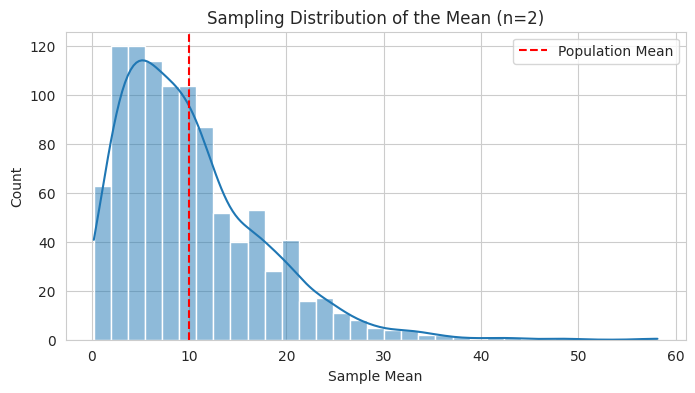

Visualizing CLT with n=10 (Becoming bell-shaped, less skewed)


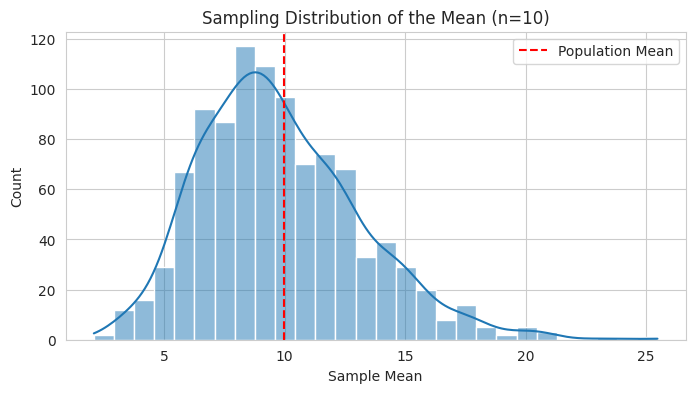

Visualizing CLT with n=50 (Approaching normality, narrower spread)


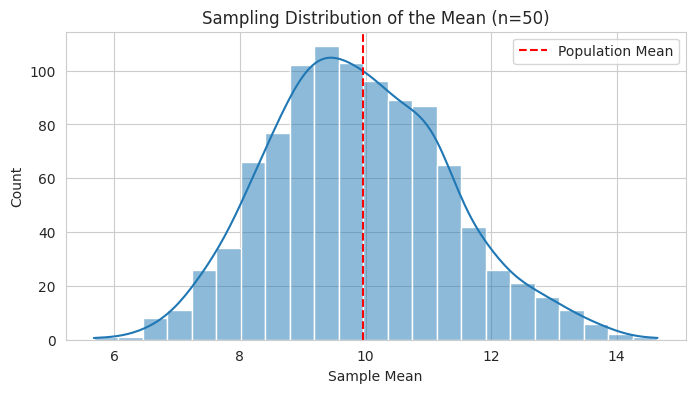

In [9]:
def visualize_clt(population, sample_size, num_samples=1000):
    """Simulates the sampling distribution of the mean."""
    sample_means = []
    for _ in range(num_samples):
        # Draw a sample from the population
        sample = np.random.choice(population, size=sample_size)
        # Calculate the mean of the sample
        sample_means.append(np.mean(sample))

    # Plot the distribution of the sample means
    plt.figure(figsize=(8, 4))
    sns.histplot(sample_means, kde=True)
    plt.title(f'Sampling Distribution of the Mean (n={sample_size})')
    plt.xlabel('Sample Mean')
    # Center the plot around the population mean
    pop_mean = np.mean(population)
    plt.axvline(pop_mean, color='red', linestyle='--', label='Population Mean')
    plt.legend()
    plt.show()

# Case 1: Very small sample size (n=2)
print("Visualizing CLT with n=2 (Still Skewed)")
visualize_clt(exponential_population, sample_size=2)

# Case 2: Medium sample size (n=10)
print("Visualizing CLT with n=10 (Becoming bell-shaped, less skewed)")
visualize_clt(exponential_population, sample_size=10)

# Case 3: Large sample size (n=50)
print("Visualizing CLT with n=50 (Approaching normality, narrower spread)")
visualize_clt(exponential_population, sample_size=50)

### Observation
Even though the population was highly skewed (Exponential), the distribution of sample means quickly becomes Normal as 'n' increases. Also, note how the distribution becomes narrower (the Standard Error decreases) as 'n' increases, meaning our estimates become more precise and centered around the true population mean.